In [ ]:
# Netflix Data Analysis

In [7]:
# step 1
import pandas as pd
import numpy as np
netflix_dataset = pd.read_csv("Dataset.csv")
netflix_dataset.head()
# imported the Netflix dataset using Pandas read_csv function and
#stored it in a DataFrame called netflix_dataset "

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [14]:
print(netflix_dataset.isnull().sum())
# checking for null/missing values 
# it has given the count of how many null values are there in the columns

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [13]:
# Few columns does not contain actual values but " not given " is mentioned instead and pandas does not actually count this 
# as null value 
#checking for the not given values in the various cells
print((netflix_dataset == "Not Given").sum())

show_id            0
type               0
title              0
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64


In [ ]:
# No actual null values were found in the Netflix dataset. However, some fields contain "Not Given", 
# which represents unavailable information. 
# These records were retained because the rest of the information in those records is still useful for analysis.

In [17]:
# checking for duplicate in the record
netflix_dataset.duplicated().sum()

0

In [21]:
# checking formatting inconsistency
# this will help in cleaning unnecessary spaces from the important text columns
netflix_dataset['country'] = netflix_dataset['country'].str.strip()
netflix_dataset['rating'] = netflix_dataset['rating'].str.strip()
netflix_dataset['type'] = netflix_dataset['type'].str.strip()

In [23]:
# Standardize Country, Rating and Type

# Country - remove unnecessary spaces
netflix_dataset['country'] = netflix_dataset['country'].str.strip()

# Rating - remove spaces and convert to uppercase
netflix_dataset['rating'] = netflix_dataset['rating'].str.strip().str.upper()

# Type - remove unnecessary spaces
netflix_dataset['type'] = netflix_dataset['type'].str.strip()

In [25]:
print(netflix_dataset['country'].value_counts().head(10))
print(netflix_dataset['rating'].value_counts())
print(netflix_dataset['type'].value_counts())

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [27]:
#  Exported the cleaned dataset

# Check final shape
print("Final dataset shape:", netflix_dataset.shape)

# Check duplicates
print("Final duplicate count:", netflix_dataset.duplicated().sum())

# Export
netflix_dataset.to_csv("Netflix_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Final dataset shape: (8790, 10)
Final duplicate count: 0
Cleaned dataset exported successfully!


In [2]:
# exporting the cleaned dataset
import pandas as pd
netflix_dataset = pd.read_csv("Netflix_Cleaned.csv")

In [3]:
netflix_dataset.head(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [4]:
# Calculating the total number of Movies and TV
netflix_dataset['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

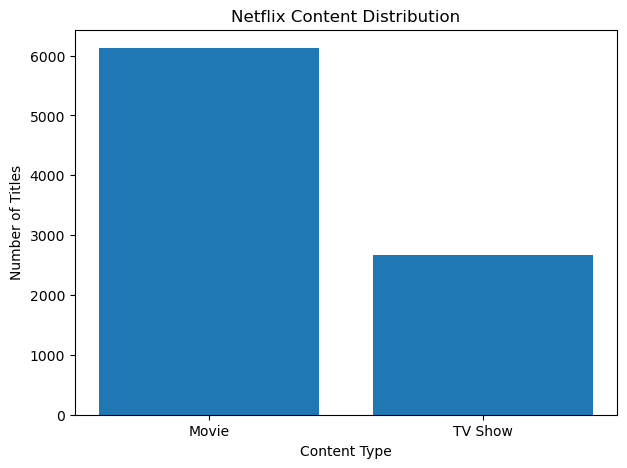

In [5]:
# Creating  visualizations for content distribution.
import matplotlib.pyplot as plt

content_count = netflix_dataset['type'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(content_count.index, content_count.values)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Distribution")

plt.show()

In [6]:
# Comparing content proportions.
content_count = netflix_dataset['type'].value_counts()
content_percentage = netflix_dataset['type'].value_counts(normalize=True) * 100

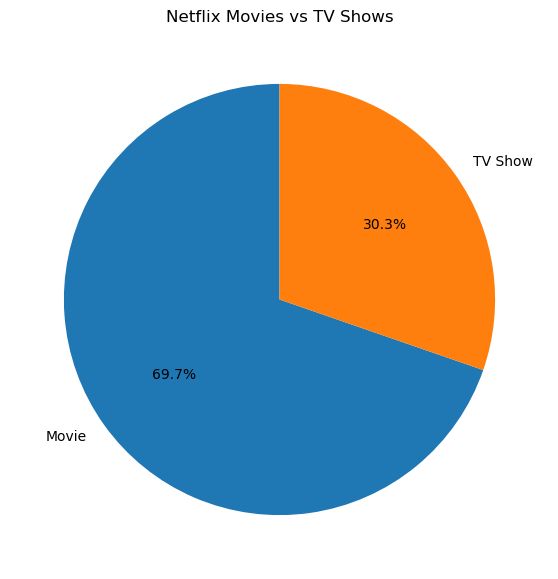

In [7]:
plt.figure(figsize=(7,7))

plt.pie(
    content_count.values,
    labels=content_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Netflix Movies vs TV Shows")

plt.show()

In [9]:
 #Extracting  and clean country information
import pandas as pd
netflix_dataset = pd.read_csv("Netflix_Cleaned.csv")
country_data = netflix_dataset.assign(
    country=netflix_dataset['country'].str.split(',')
).explode('country')

# Removing unnecessary spaces
country_data['country'] = country_data['country'].str.strip()

# Checking the result
country_data[['title', 'country']].head(20)

,title,country
0,Dick Johnson Is Dead,United States
1,Ganglands,France
2,Midnight Mass,United States
3,Confessions of an Invisible Girl,Brazil
4,Sankofa,United States
5,The Great British Baking Show,United Kingdom
6,The Starling,United States
7,Motu Patlu in the Game of Zones,India
8,Je Suis Karl,Germany
9,Motu Patlu in Wonderland,India


In [10]:
country_data = netflix_dataset.assign(
    country=netflix_dataset['country'].str.split(',')
).explode('country')

country_data['country'] = country_data['country'].str.strip()

country_data[['title', 'country']].head(20)

,title,country
0,Dick Johnson Is Dead,United States
1,Ganglands,France
2,Midnight Mass,United States
3,Confessions of an Invisible Girl,Brazil
4,Sankofa,United States
5,The Great British Baking Show,United Kingdom
6,The Starling,United States
7,Motu Patlu in the Game of Zones,India
8,Je Suis Karl,Germany
9,Motu Patlu in Wonderland,India


In [11]:
# Calculating content count by country

country_count = country_data.groupby('country')['title'].count()

# Sort from highest to lowest
country_count = country_count.sort_values(ascending=False)

# Display top 10 countries
print(country_count.head(10))

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: title, dtype: int64


In [12]:
#Identifying top content-producing countries

top_countries = country_count.head(10).reset_index()

top_countries.columns = ['Country', 'Content_Count']

print(top_countries)

          Country  Content_Count
0   United States           3240
1           India           1057
2  United Kingdom            638
3        Pakistan            421
4       Not Given            287
5          Canada            271
6           Japan            259
7     South Korea            214
8          France            213
9           Spain            182


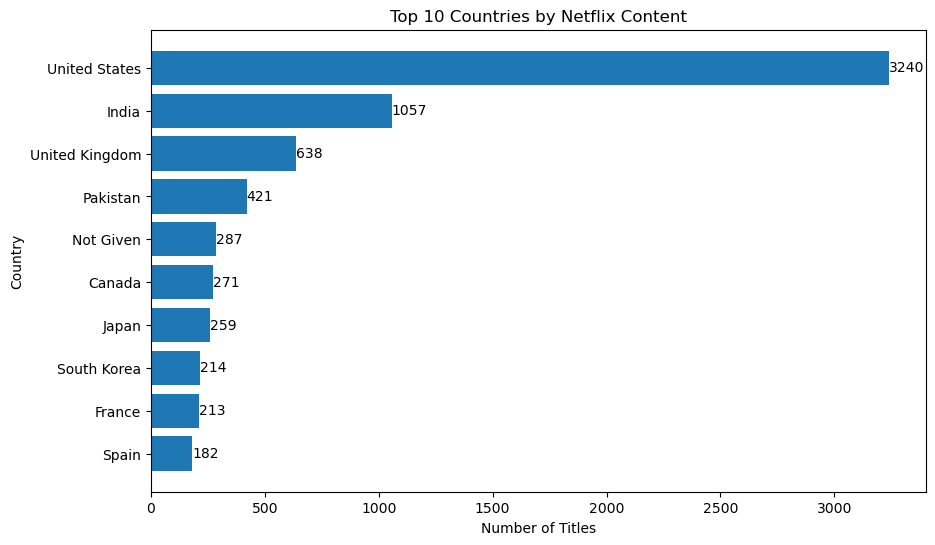

In [13]:
# Creating charts and rankings

import matplotlib.pyplot as plt

# Reverse order so highest appears at the top
top_countries_chart = top_countries.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_countries_chart['Country'],
    top_countries_chart['Content_Count']
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.title("Top 10 Countries by Netflix Content")

# Add values to bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center'
    )

plt.show()

In [14]:
# Generating business insights
# ------------------------------------------------

# Total content associations
all_country_total = country_count.sum()

# Total content associations of top 10 countries
top_10_total = top_countries['Content_Count'].sum()

# Percentage contributed by top 10
top_10_percentage = (top_10_total / all_country_total) * 100

print("\n========== BUSINESS INSIGHTS ==========")

print(
    "Top country:",
    top_countries.iloc[0]['Country']
)

print(
    "Top country content count:",
    top_countries.iloc[0]['Content_Count']
)

print(
    "Top 10 countries account for:",
    round(top_10_percentage, 2),
    "% of all country-content associations."
)

print(
    "\nThe analysis shows that Netflix content is distributed "
    "across multiple countries, with a larger concentration "
    "among the top content-associated countries."
)


========== BUSINESS INSIGHTS ==========
Top country: United States
Top country content count: 3240
Top 10 countries account for: 77.16 % of all country-content associations.

The analysis shows that Netflix content is distributed across multiple countries, with a larger concentration among the top content-associated countries.


In [15]:
#Organizing content by release year

import pandas as pd

# Loaded cleaned dataset
netflix_dataset = pd.read_csv("Netflix_Cleaned.csv")

# Convert release_year into numeric format
netflix_dataset['release_year'] = pd.to_numeric(
    netflix_dataset['release_year'],
    errors='coerce'
)

# Checking the release year column
print("Release Year:")
print(netflix_dataset['release_year'].head())

# Check data type
print("\nData Type:")
print(netflix_dataset['release_year'].dtype)

Release Year:
0    2020
1    2021
2    2021
3    2021
4    1993
Name: release_year, dtype: int64

Data Type:
int64


In [17]:
# CALCULATEING YEARLY CONTENT RELEASES


# Count the number of titles for each release year
yearly_content = netflix_dataset['release_year'].value_counts()

# Sort years chronologically
yearly_content = yearly_content.sort_index()

# Display yearly content count
print("Number of Netflix Titles by Release Year:")
print(yearly_content)

# Convert the result into a DataFrame
yearly_content_df = yearly_content.reset_index()

# Rename columns
yearly_content_df.columns = [
    'Release_Year',
    'Content_Count'
]

print("\nYearly Content DataFrame:")
print(yearly_content_df)

Number of Netflix Titles by Release Year:
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

Yearly Content DataFrame:
    Release_Year  Content_Count
0           1925              1
1           1942              2
2           1943              3
3           1944              3
4           1945              4
..           ...            ...
69          2017           1030
70          2018           1146
71          2019           1030
72          2020            953
73          2021            592

[74 rows x 2 columns]


In [18]:
#  IDENTIFYING GROWTH AND DECLINE TRENDS

# Find the year with the highest number of releases
highest_year = yearly_content.idxmax()
highest_count = yearly_content.max()

# Find the year with the lowest number of releases
lowest_year = yearly_content.idxmin()
lowest_count = yearly_content.min()

# Display highest and lowest years
print("Year with Highest Content Releases:")
print(highest_year)

print("\nHighest Number of Titles:")
print(highest_count)

print("\nYear with Lowest Content Releases:")
print(lowest_year)

print("\nLowest Number of Titles:")
print(lowest_count)


yearly_change = yearly_content.diff()

print("\nYear-over-Year Change:")
print(yearly_change)

yearly_percentage_change = (
    yearly_content.pct_change() * 100
)

print("\nYear-over-Year Percentage Change:")
print(yearly_percentage_change)

Year with Highest Content Releases:
2018

Highest Number of Titles:
1146

Year with Lowest Content Releases:
1925

Lowest Number of Titles:
1

Year-over-Year Change:
release_year
1925      NaN
1942      1.0
1943      1.0
1944      0.0
1945      1.0
        ...  
2017    129.0
2018    116.0
2019   -116.0
2020    -77.0
2021   -361.0
Name: count, Length: 74, dtype: float64

Year-over-Year Percentage Change:
release_year
1925           NaN
1942    100.000000
1943     50.000000
1944      0.000000
1945     33.333333
           ...    
2017     14.317425
2018     11.262136
2019    -10.122164
2020     -7.475728
2021    -37.880378
Name: count, Length: 74, dtype: float64


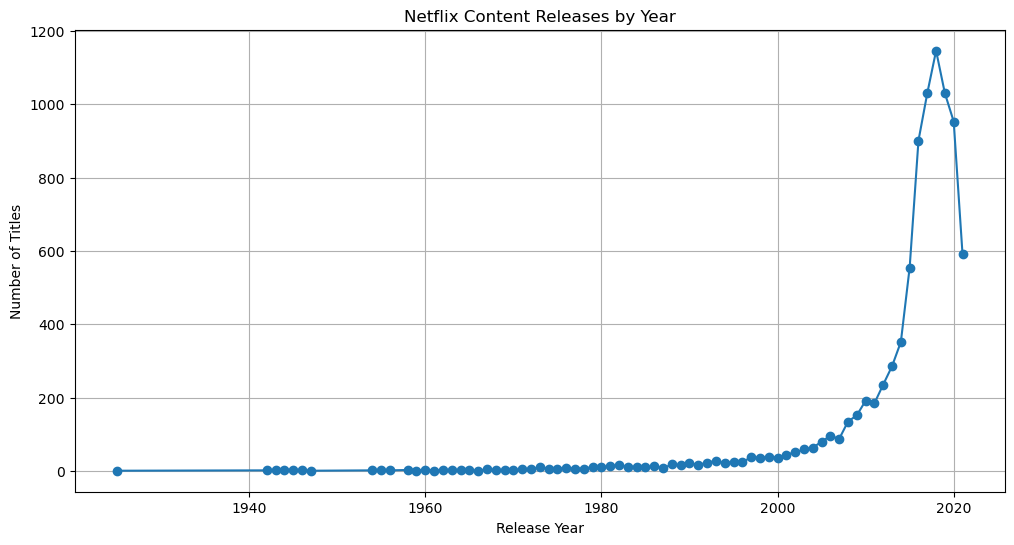

In [19]:
# CREATING TREND VISUALIZATIONS

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o'
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Releases by Year")

plt.grid(True)

plt.show()

In [20]:
# STEP 5: INTERPRETING BUSINESS PATTERNS

# Find the top 10 years with the highest
# number of Netflix titles
top_years = (
    yearly_content
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Years by Number of Titles:")
print(top_years)


print("\n========== BUSINESS INSIGHTS ==========")

print(
    "Year with highest number of titles:",
    highest_year
)

print(
    "Number of titles in that year:",
    highest_count
)
print(
    "\nYear with lowest number of titles:",
    lowest_year
)

print(
    "Number of titles in that year:",
    lowest_count
)

print(
    "\nThe analysis shows how Netflix titles "
    "are distributed across different release years."
)

print(
    "The trend can be used to identify periods "
    "with relatively higher or lower content releases."
)

print(
    "\nImportant: release_year represents the "
    "release year of the title, not necessarily "
    "the year when Netflix added the title."
)

Top 10 Years by Number of Titles:
release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64

========== BUSINESS INSIGHTS ==========
Year with highest number of titles: 2018
Number of titles in that year: 1146

Year with lowest number of titles: 1925
Number of titles in that year: 1

The analysis shows how Netflix titles are distributed across different release years.
The trend can be used to identify periods with relatively higher or lower content releases.

Important: release_year represents the release year of the title, not necessarily the year when Netflix added the title.
